In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc 
from sklearn.metrics import f1_score
import json
from pathlib import Path
from datetime import datetime

import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_gait import *
from src.plot_data_gait import *
from src.train_LSTMGait import train_model, predict_trial

In [2]:
RESULTS_PATH = Path("results/model_scores.csv")
RESULTS_PATH.parent.mkdir(exist_ok=True)

def log_result(model_name, f1_val, f1_test, seed=None, **extra):
    row = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model": model_name,
        "f1_val": f1_val,
        "f1_test": f1_test,
        **extra,
    }
    df_new = pd.DataFrame([row])
    if RESULTS_PATH.exists():
        df = pd.concat([pd.read_csv(RESULTS_PATH), df_new], ignore_index=True)
    else:
        df = df_new
    df.to_csv(RESULTS_PATH, index=False)


In [3]:
base_path = '../datasets/GAIT_signals/dataset/data'

In [4]:
lr = 0.001
dropout = 0.5
cnn_channels = [64, 128, 128]
kernel_size = 7
batch_size = 128

# LB Only

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_only"

ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59352  |  test: 17108
               →  train: 166 subjects (46063 windows)  |  val: 42 subjects (13289 windows)


Early stopping in epoch 57. Best F1: 0.8623

Val F1: 0.8623  |  Test F1: 0.8724
Checkpoint saved → ../checkpoints/best_model_LB_only\model.pt


In [6]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8623
Test F1 score: 0.8724


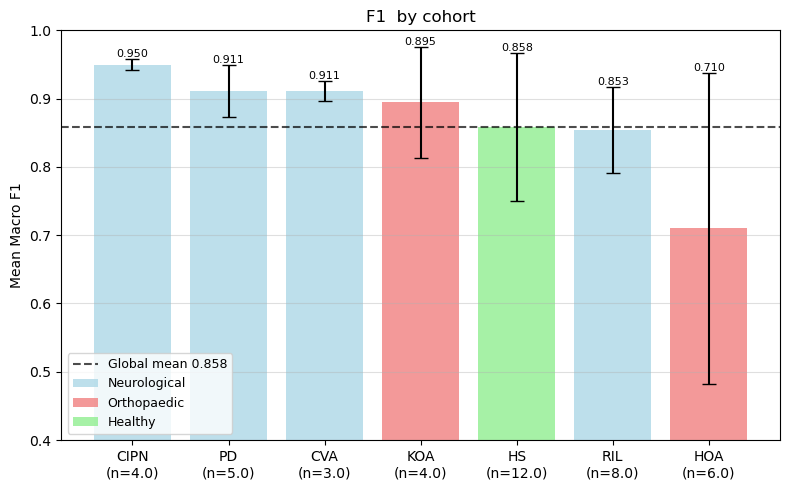

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + Right foot

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'RF'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_RF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59193  |  test: 17106
               →  train: 166 subjects (45943 windows)  |  val: 42 subjects (13250 windows)


Early stopping in epoch 52. Best F1: 0.8914

Val F1: 0.8914  |  Test F1: 0.9249
Checkpoint saved → ../checkpoints/best_model_LB_RF\model.pt


In [10]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8914
Test F1 score: 0.9249


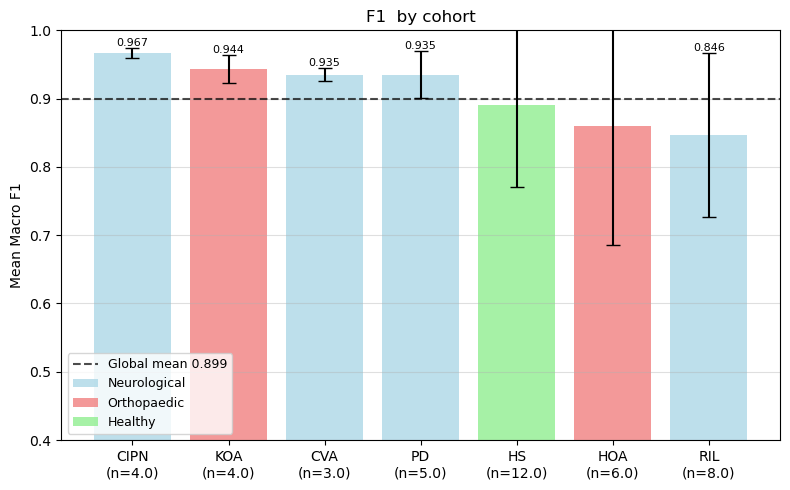

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + Left foot

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'LF'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_LF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59336  |  test: 17107
               →  train: 166 subjects (46048 windows)  |  val: 42 subjects (13288 windows)


Early stopping in epoch 99. Best F1: 0.9010

Val F1: 0.9010  |  Test F1: 0.9249
Checkpoint saved → ../checkpoints/best_model_LB_LF\model.pt


In [14]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.9010
Test F1 score: 0.9249


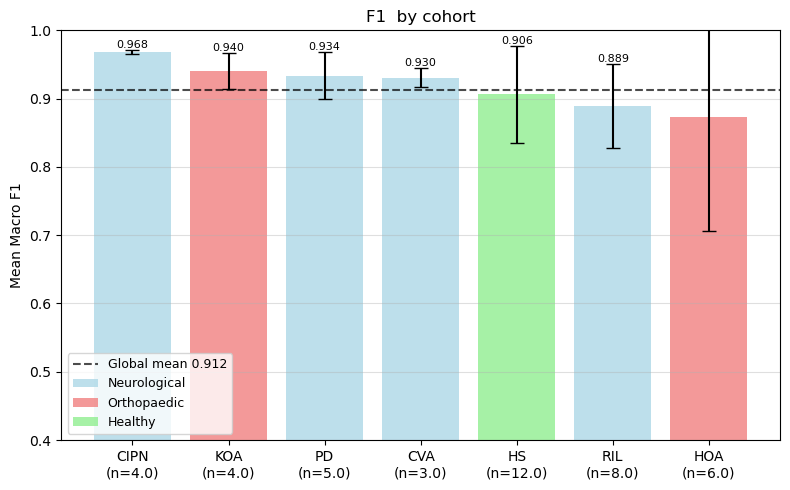

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + Affected foot

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'affected'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_affected"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59335  |  test: 17107
               →  train: 166 subjects (46048 windows)  |  val: 42 subjects (13287 windows)


Early stopping in epoch 102. Best F1: 0.8857

Val F1: 0.8857  |  Test F1: 0.9154
Checkpoint saved → ../checkpoints/best_model_LB_affected\model.pt


In [18]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8857
Test F1 score: 0.9154


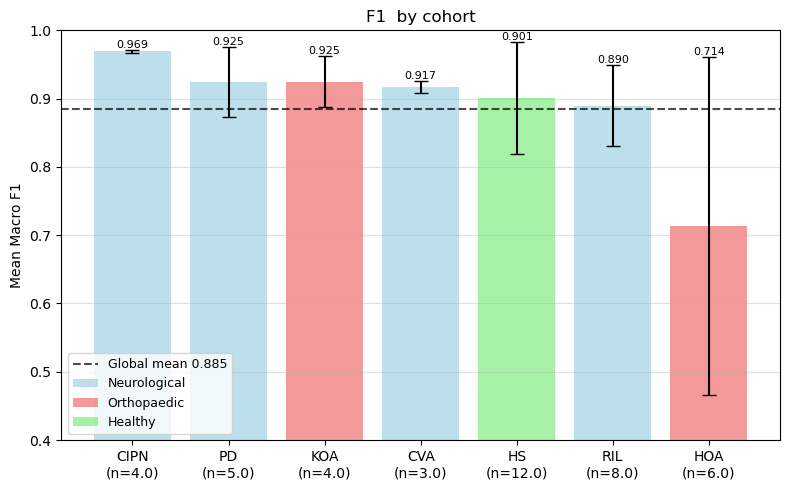

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + Non affected foot

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'non_affected'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_non_affected"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59337  |  test: 17106
               →  train: 166 subjects (46050 windows)  |  val: 42 subjects (13287 windows)


Early stopping in epoch 66. Best F1: 0.8909

Val F1: 0.8909  |  Test F1: 0.9153
Checkpoint saved → ../checkpoints/best_model_LB_non_affected\model.pt


In [22]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8909
Test F1 score: 0.9153


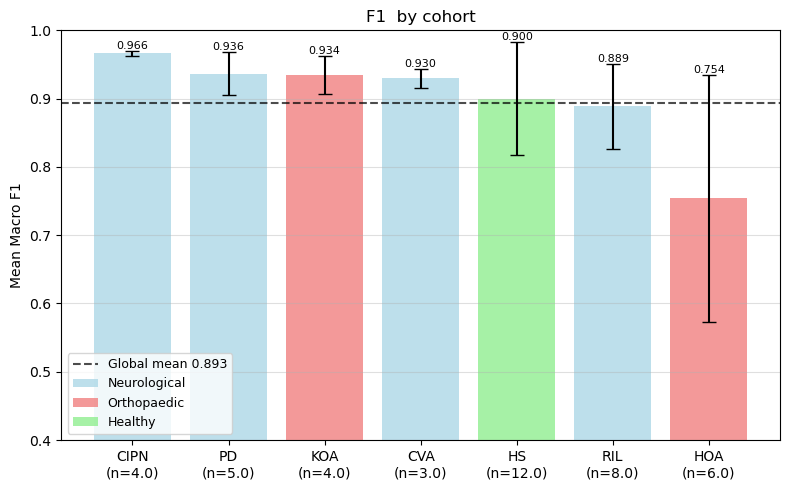

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# RF + LF

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['RF', 'LF'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_RF_LF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59337  |  test: 17106
               →  train: 166 subjects (46050 windows)  |  val: 42 subjects (13287 windows)


Early stopping in epoch 66. Best F1: 0.8909

Val F1: 0.8909  |  Test F1: 0.9153
Checkpoint saved → ../checkpoints/best_model_LB_non_affected\model.pt


In [ ]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8909
Test F1 score: 0.9153


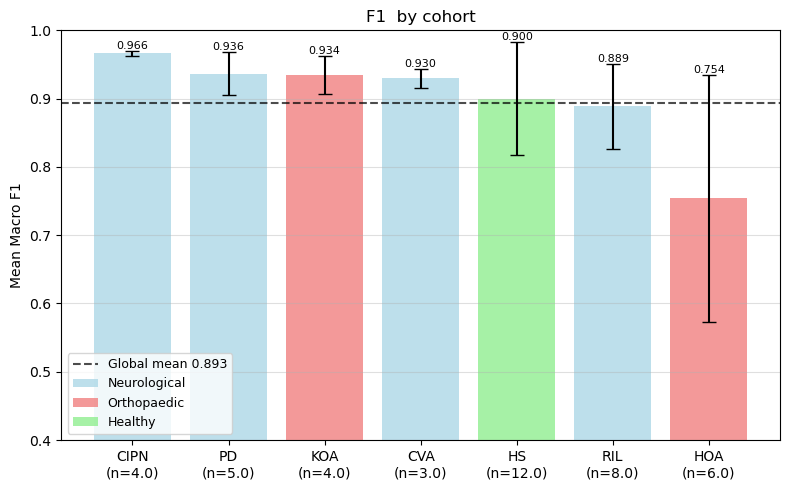

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + RF + LF

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'RF', 'LF'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_RF_LF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59337  |  test: 17106
               →  train: 166 subjects (46050 windows)  |  val: 42 subjects (13287 windows)


Early stopping in epoch 66. Best F1: 0.8909

Val F1: 0.8909  |  Test F1: 0.9153
Checkpoint saved → ../checkpoints/best_model_LB_non_affected\model.pt


In [ ]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8909
Test F1 score: 0.9153


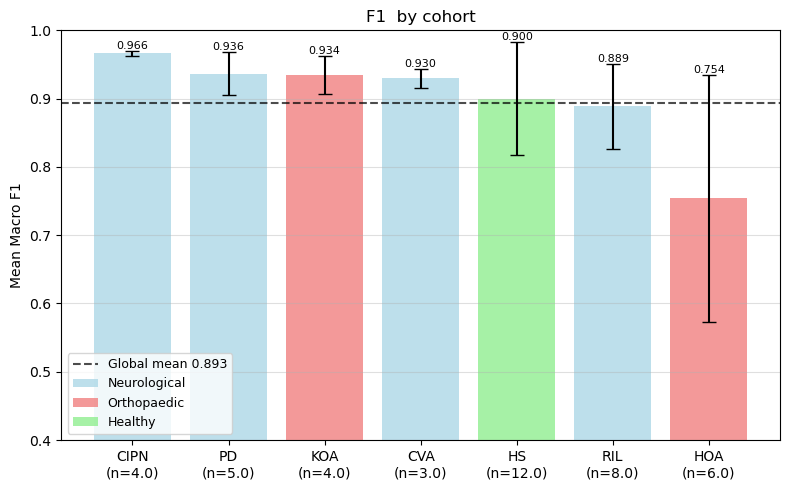

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# HE

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['HE'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_HE"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59337  |  test: 17106
               →  train: 166 subjects (46050 windows)  |  val: 42 subjects (13287 windows)


Early stopping in epoch 66. Best F1: 0.8909

Val F1: 0.8909  |  Test F1: 0.9153
Checkpoint saved → ../checkpoints/best_model_LB_non_affected\model.pt


In [ ]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8909
Test F1 score: 0.9153


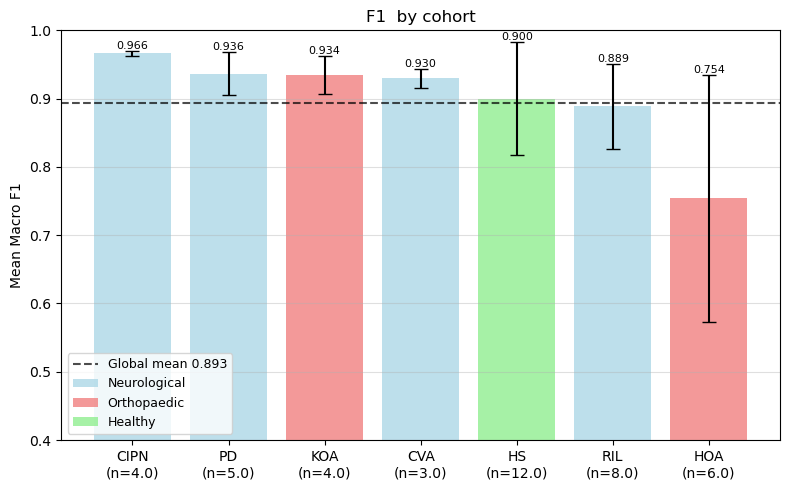

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# RF

In [6]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['RF'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_RF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [7]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59202  |  test: 17106
               →  train: 166 subjects (45951 windows)  |  val: 42 subjects (13251 windows)


Early stopping in epoch 76. Best F1: 0.8704

Val F1: 0.8704  |  Test F1: 0.8912
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_RF/model.pt


In [8]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8704
Test F1 score: 0.8912


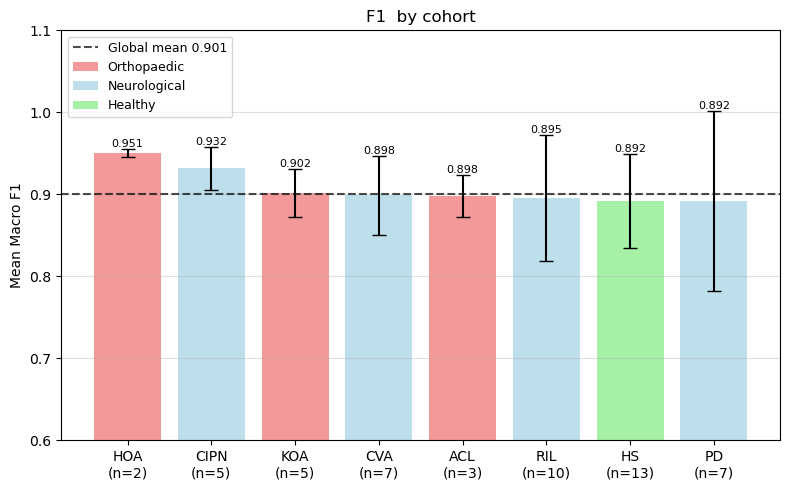

In [9]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LF

In [10]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LF'], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [11]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59358  |  test: 17107
               →  train: 166 subjects (46068 windows)  |  val: 42 subjects (13290 windows)


Early stopping in epoch 41. Best F1: 0.8866

Val F1: 0.8866  |  Test F1: 0.8982
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_LF/model.pt


In [12]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8866
Test F1 score: 0.8982


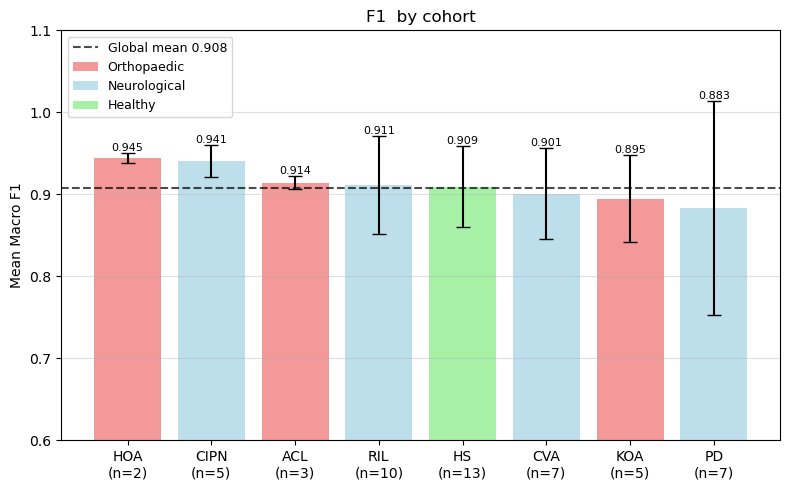

In [13]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# All sensors

In [14]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_all_sensors"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [15]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59183  |  test: 17104
               →  train: 166 subjects (45933 windows)  |  val: 42 subjects (13250 windows)


Early stopping in epoch 83. Best F1: 0.9164

Val F1: 0.9164  |  Test F1: 0.9463
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_all_sensors/model.pt


In [16]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.9164
Test F1 score: 0.9463


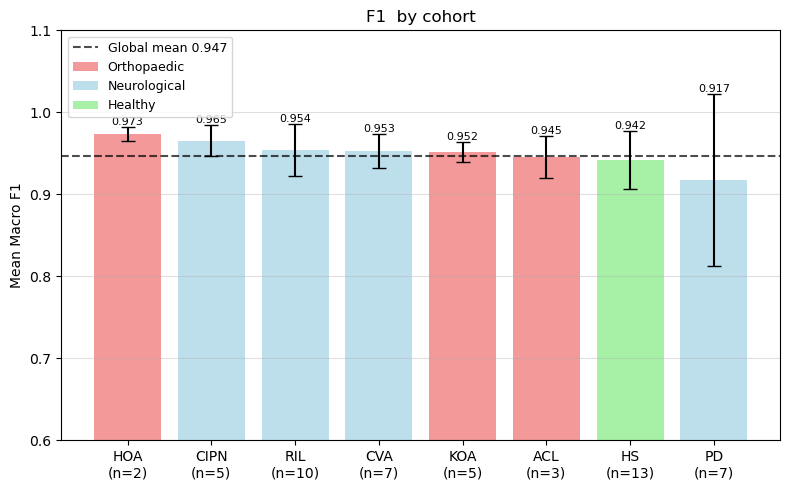

In [17]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# All sensors processed

In [19]:
X, y, subjects = load_dataset_gait(base_path, process="preprocessed", window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_all_sensors_processed"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [20]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)

log_result(model_name, f1_val=best_val_f1, f1_test=test_f1)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59459  |  test: 17121
               →  train: 166 subjects (46136 windows)  |  val: 42 subjects (13323 windows)


Early stopping in epoch 81. Best F1: 0.9663

Val F1: 0.9663  |  Test F1: 0.9626
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_all_sensors_processed/model.pt


In [21]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.9663
Test F1 score: 0.9626


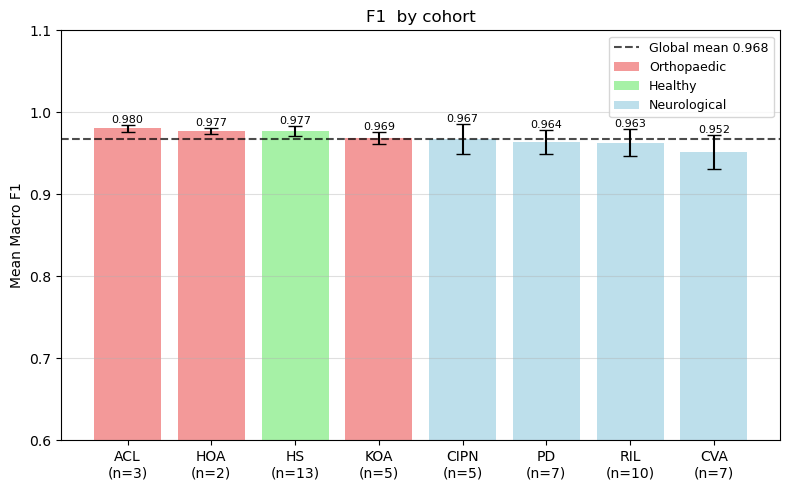

In [22]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# Result Comparison

In [ ]:
results = pd.read_csv(RESULTS_PATH)

